# Analisis y graficos

En esta libreta realizamos los analisis plateados en la [Libreta_planteamiento_de_insights](Libreta_planteamiento_de_insights.ipynb), usando los dos dataframes `df_player_latest` y `df_team_match` elaborados en la [Libreta_procesamiento_de_datos](Libreta_procesamiento_de_datos.ipynb).

## Lectura de datos y formateo basico

El script final va a continuar de la parte de procesado, por lo cual no se tendra que hacer lo que hacemos a continuacion. Esto solo es para segmentar los avances en distintas libretas de jupyter.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import math
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

In [64]:
df_team_match = pd.read_csv("../OUTPUTS/df_team_match.csv")
df_player_latest_imputed = pd.read_csv("../OUTPUTS/df_player_latest_imputed.csv")
df_player_latest = pd.read_csv("../OUTPUTS/df_player_latest.csv")

df_team_match["DATE"] = pd.to_datetime(df_team_match["DATE"], errors="coerce").dt.floor("s")

df_player_latest["DATE"] = pd.to_datetime(df_player_latest["DATE"], errors="coerce").dt.floor("s")
df_player_latest["BIRTHDAY"] = pd.to_datetime(df_player_latest["BIRTHDAY"], errors="coerce").dt.floor("s")

df_player_latest_imputed["DATE"] = pd.to_datetime(df_player_latest_imputed["DATE"], errors="coerce").dt.floor("s")
df_player_latest_imputed["BIRTHDAY"] = pd.to_datetime(df_player_latest_imputed["BIRTHDAY"], errors="coerce").dt.floor("s")

# display(df_team_match.info())
# display(df_player_latest.info())
# display(df_player_latest_imputed.info())

In [65]:
COLOR_FONDO = "#F7F7F2"
COLOR_TEXTO = "#1F2937"
COLOR_GRID = "#D0D7DE"

COLOR_PRINCIPAL = "#1D4E89"
COLOR_SECUNDARIO = "#2A9D8F"
COLOR_RESALTE = "#E9C46A"
COLOR_ALERTA = "#D95D39"
COLOR_NEUTRO = "#8D99AE"

PALETA = [
    COLOR_PRINCIPAL,
    COLOR_SECUNDARIO,
    COLOR_RESALTE,
    COLOR_ALERTA,
    COLOR_NEUTRO,
    "#84A59D"
]

CMAP_CORR = "RdBu_r"

plt.rcParams.update({
    "figure.facecolor": COLOR_FONDO,
    "axes.facecolor": COLOR_FONDO,
    "savefig.facecolor": COLOR_FONDO,
    "axes.edgecolor": "#AAB4BE",
    "axes.labelcolor": COLOR_TEXTO,
    "axes.titlecolor": COLOR_TEXTO,
    "xtick.color": COLOR_TEXTO,
    "ytick.color": COLOR_TEXTO,
    "text.color": COLOR_TEXTO,
    "grid.color": COLOR_GRID,
    "grid.alpha": 0.35,
    "font.family": "sans-serif",
    "font.sans-serif": ["Aptos", "Segoe UI", "Calibri", "DejaVu Sans"],
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120
})

## Analisis 01: Que atributos de jugador de campo aportan informacion nueva y cuales son redundantes?

- Pregunta: Que atributos conviene mirar juntos y cuales son casi equivalentes al evaluar futbolistas de campo?
- Que se calcula?: Una matriz de correlacion entre variables numericas de Player_Attributes enfocado en jugadores de campo.
- Datos a usar: df_player_latest
- Grafico: Heatmap de correlaciones.
- Insight esperado: Simplificar criterios de scouting y evitar evaluar como si fueran independientes atributos que casi siempre se mueven juntos.

Como el usar datos nan complicaria el analisis, usaremos el `df_player_latest_imputed`.

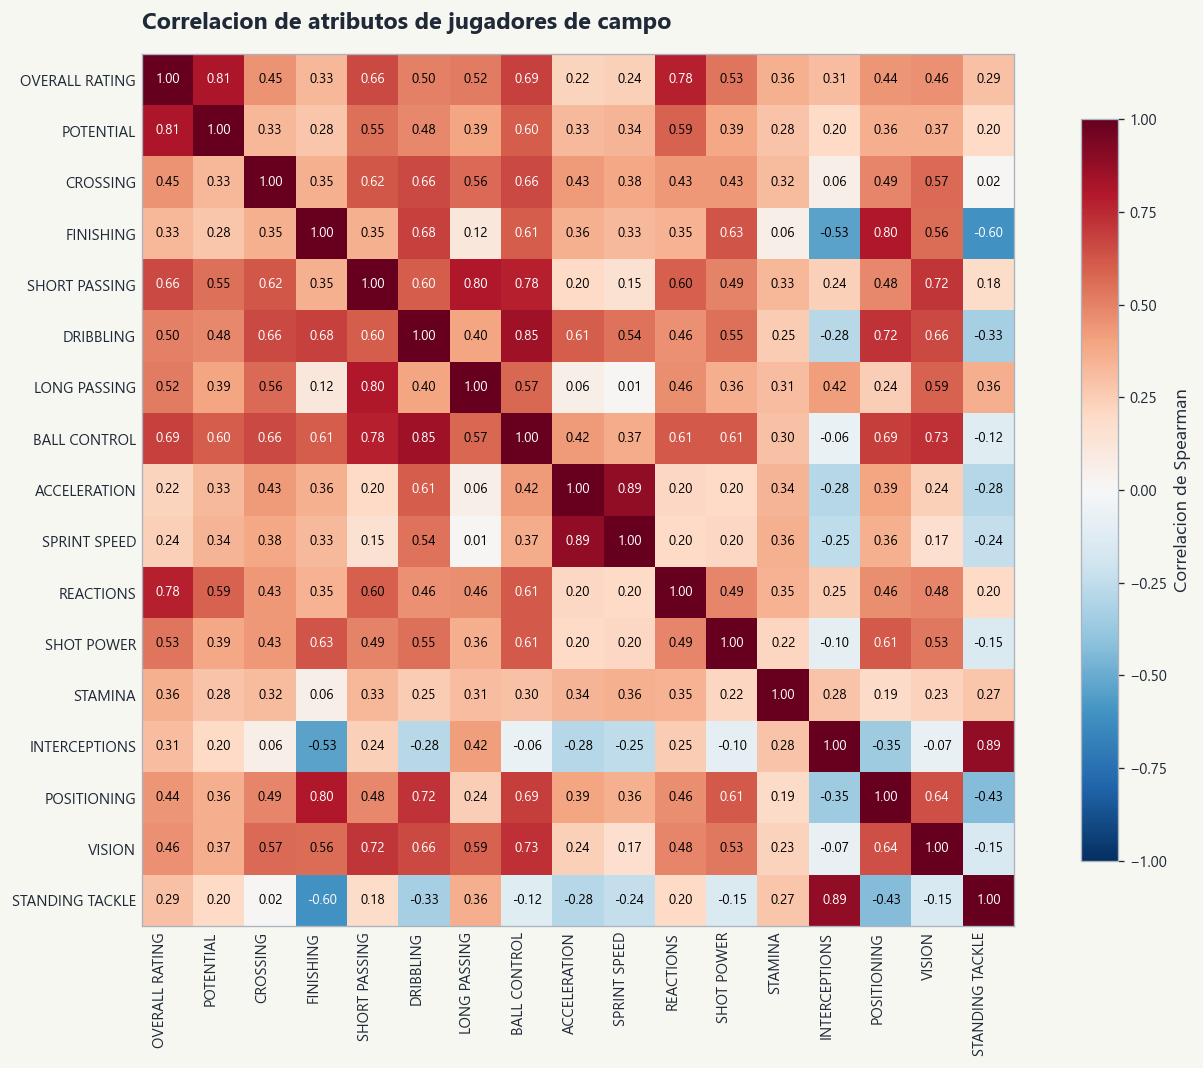

In [66]:
# Nos quedamos solo con jugadores de campo
df_outfield = df_player_latest_imputed.copy()
df_outfield = df_outfield[df_outfield["PLAYER_TYPE"] == "OUTFIELD"]

# Seleccionamos atributos relevantes para jugadores de campo
cols = [
    "OVERALL_RATING",
    "POTENTIAL",
    "CROSSING",
    "FINISHING",
    "SHORT_PASSING",
    "DRIBBLING",
    "LONG_PASSING",
    "BALL_CONTROL",
    "ACCELERATION",
    "SPRINT_SPEED",
    "REACTIONS",
    "SHOT_POWER",
    "STAMINA",
    "INTERCEPTIONS",
    "POSITIONING",
    "VISION",
    "STANDING_TACKLE"
]

# Calculamos la matriz de correlacion
df_corr = df_outfield[cols].copy()
corr = df_corr.corr(method = "spearman")

# Preparamos labels mas limpios para el grafico
labels = [col.replace("_", " ") for col in corr.columns]

# Graficamos el heatmap
fig, ax = plt.subplots(figsize = (12, 9))
im = ax.imshow(corr.values, cmap = CMAP_CORR, vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) >= 0.60 else "black"
        text = ax.text(j, i, f"{value:.2f}", ha = "center", va = "center", color = color, fontsize = 8)

ax.set_title("Correlacion de atributos de jugadores de campo", loc = "left", pad = 15)
ax.tick_params(length = 0)
cbar = plt.colorbar(im, ax = ax, shrink=0.85)
cbar.set_label("Correlacion de Spearman")

fig.tight_layout()
plt.show()

### Análisis del gráfico

En el heatmap de jugadores de campo se observan bloques claros de atributos que se mueven casi juntos. Por ejemplo, `ACCELERATION` y `SPRINT_SPEED` tienen una correlación muy alta (`0.89`), lo que sugiere que ambas variables describen casi la misma dimensión de rapidez. Algo parecido ocurre con `INTERCEPTIONS` y `STANDING_TACKLE` (`0.89`), que representan un perfil defensivo muy similar.

También aparece un bloque técnico-ofensivo bastante marcado. `DRIBBLING` y `BALL_CONTROL` tienen una correlación alta (`0.85`), mientras que `SHORT_PASSING` y `LONG_PASSING` también se relacionan fuertemente (`0.80`). Además, `FINISHING` y `POSITIONING` muestran una correlación importante (`0.80`), lo que indica que los jugadores que suelen ubicarse mejor en zonas de ataque también tienden a definir mejor.

A nivel general, `OVERALL_RATING` se relaciona bastante con `POTENTIAL` (`0.81`) y con `REACTIONS` (`0.78`). Esto sugiere que la valoración global del jugador no depende de un solo atributo aislado, sino de combinaciones de técnica, lectura de juego y capacidad física. En otras palabras, para scouting de jugadores de campo no conviene tratar todas estas variables como independientes, porque varias son parcialmente redundantes y pueden resumirse por bloques.

## Analisis 02: Que atributos de jugador portero aportan informacion nueva y cuales son redundantes?

- Pregunta: Que atributos conviene mirar juntos y cuales son casi equivalentes al evaluar futbolistas?
- Que se calcula?: Una matriz de correlacion entre variables numericas de Player_Attributes, idealmente usando correlacion de Spearman y separando jugadores de campo y porteros.
- Datos a usar: df_player_latest
- Grafico: Heatmap de correlaciones.
- Precauciones: Usar un solo snapshot por jugador; no incluir IDs, fechas ni variables de portero si se mezclan jugadores de campo; revisar valores faltantes y outliers.
- Como identificar si el resultado es relevante?: Si aparecen bloques claros de correlacion alta, por ejemplo velocidad, pase, defensa o fisico, y si eso permite reducir variables redundantes.
- Insight esperado: Simplificar criterios de scouting y evitar evaluar como si fueran independientes atributos que casi siempre se mueven juntos.

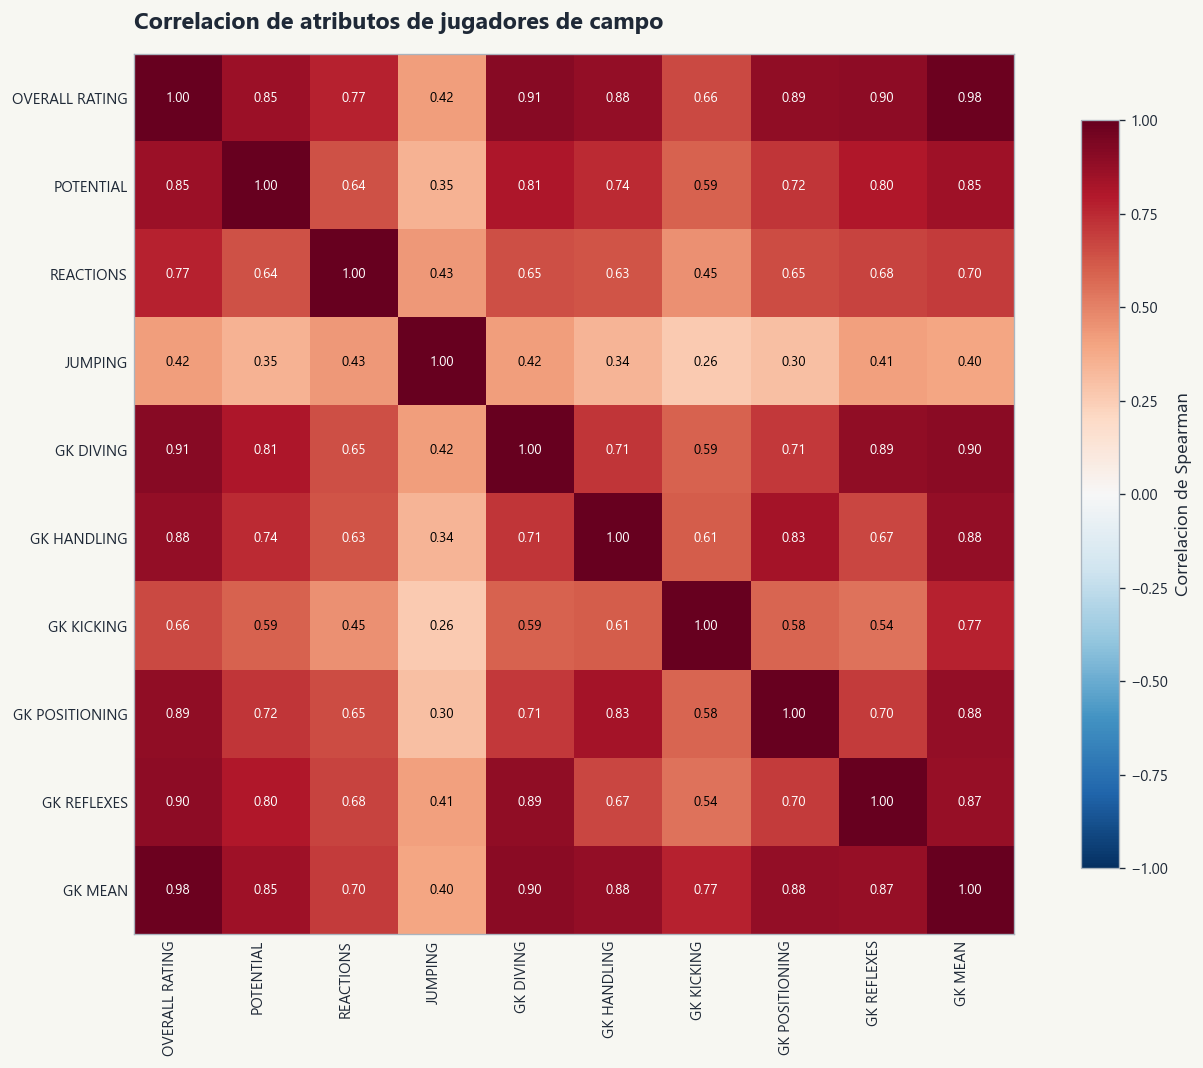

In [67]:
# Nos quedamos solo con porteros
df_goalkeepers = df_player_latest_imputed.copy()
df_goalkeepers = df_goalkeepers[df_goalkeepers["PLAYER_TYPE"] == "GOALKEEPER"]

# Seleccionamos atributos relevantes para porteros
cols = [
    "OVERALL_RATING",
    "POTENTIAL",
    "REACTIONS",
    "JUMPING",
    "GK_DIVING",
    "GK_HANDLING",
    "GK_KICKING",
    "GK_POSITIONING",
    "GK_REFLEXES",
    "GK_MEAN"
]

# Calculamos la matriz de correlacion
df_corr = df_goalkeepers[cols].copy()
corr = df_corr.corr(method = "spearman")

# Preparamos labels mas limpios para el grafico
labels = [col.replace("_", " ") for col in corr.columns]

# Graficamos el heatmap
fig, ax = plt.subplots(figsize = (12, 9))
im = ax.imshow(corr.values, cmap = CMAP_CORR, vmin = -1, vmax = 1)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation = 90, ha = "right")
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.values[i, j]
        color = "white" if abs(value) >= 0.60 else "black"
        text = ax.text(j, i, f"{value:.2f}", ha = "center", va = "center", color = color, fontsize = 8)

ax.set_title("Correlacion de atributos de jugadores de campo", loc = "left", pad = 15)
ax.tick_params(length = 0)

cbar = plt.colorbar(im, ax = ax, shrink = 0.85)
cbar.set_label("Correlacion de Spearman")

fig.tight_layout()
plt.show()

### Análisis del gráfico

En el heatmap de porteros se observa una estructura mucho más concentrada que en jugadores de campo. La variable `OVERALL_RATING` está fuertemente relacionada con casi todos los atributos específicos de arquero, en especial con `GK_MEAN` (`0.98`), `GK_DIVING` (`0.91`), `GK_REFLEXES` (`0.90`), `GK_POSITIONING` (`0.89`) y `GK_HANDLING` (`0.88`). Esto indica que el rendimiento general del portero está muy dominado por sus habilidades técnicas propias del puesto.

También se ven relaciones altas entre atributos internos del arco. Por ejemplo, `GK_DIVING` y `GK_REFLEXES` tienen una correlación de `0.89`, mientras que `GK_POSITIONING` y `GK_HANDLING` alcanzan `0.83`. Esto sugiere que varios indicadores del portero miden casi la misma calidad subyacente, por lo que existe bastante redundancia entre ellos.

En cambio, `JUMPING` muestra una relación bastante menor con el bloque principal de variables de arquero. Por ejemplo, su correlación con `GK_MEAN` es solo de `0.40`. Esto sugiere que el salto aporta información complementaria, pero no explica tanto el nivel global del portero como las habilidades técnicas de atajada, colocación y reflejos.

En conjunto, este gráfico sugiere que para evaluar porteros se puede resumir gran parte del perfil usando pocas variables clave, porque muchas de las métricas del puesto se mueven casi juntas. A diferencia de los jugadores de campo, aquí la redundancia es más fuerte y el perfil parece estar más concentrado en un solo bloque de rendimiento especializado.

## Analisis 03: Histograma del gap potencial - overall rating - campistas

- Tema: Distribucion del margen de desarrollo de los jugadores.
- Pregunta: Que tan comun es encontrar jugadores con una brecha grande entre su potencial y su rendimiento actual?
- Que se calcula?: La distribucion de la variable potential - overall_rating para medir cuanto margen de crecimiento tiene cada jugador.
- Datos a usar: df_player_latest
- Grafico: Histograma.
- Precauciones: Si quieren una lectura mas limpia, pueden enfocarse en jugadores jovenes; revisar que el dataset no mezcle varios snapshots por jugador; no sacar conclusiones fuertes si no revisan la edad.
- Como identificar si el resultado es relevante?: Si la distribucion muestra una cola derecha clara y permite distinguir entre jugadores con poco margen y jugadores que destacan por su potencial no desarrollado.
- Insight esperado: Definir mejor que tan raro o comun es encontrar prospectos reales y fijar umbrales practicos para shortlist de scouting.

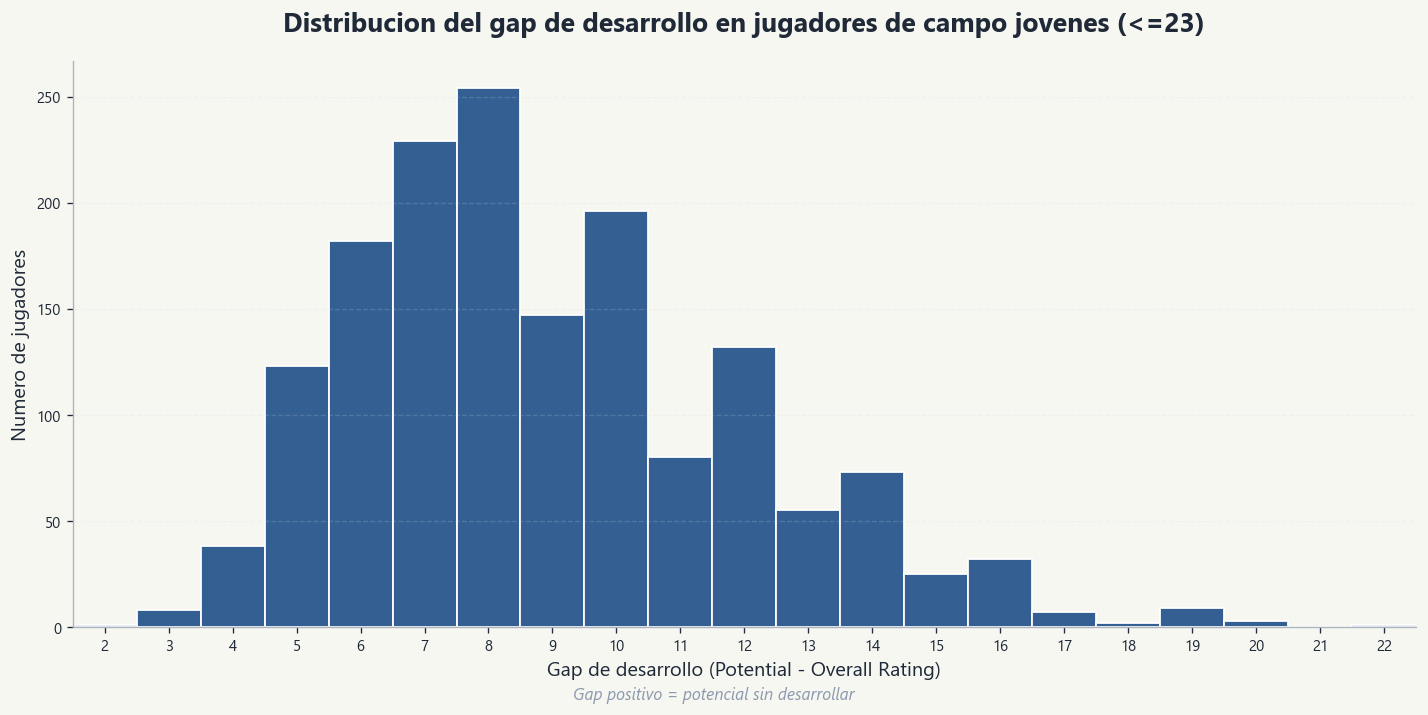

In [68]:
# Calculamos la edad de los jugadores con la misma referencia que ya venian usando
fecha_actual = pd.Timestamp("2016-01-01")
df_gap = df_player_latest_imputed.copy()
df_gap["AGE"] = (fecha_actual - df_gap["BIRTHDAY"]).dt.days / 365.25

# Filtramos solo jugadores jovenes
df_gap = df_gap[df_gap["AGE"] < 23].copy()

# Calculamos el gap entre potential y overall rating
df_gap["GAP"] = df_gap["POTENTIAL"] - df_gap["OVERALL_RATING"]

# Nos quedamos solo con jugadores de campo
df_gap_outfield = df_gap[df_gap["PLAYER_TYPE"] == "OUTFIELD"].copy()

# Como el gap es entero, usamos un bucket por valor entero
out_min = int(df_gap_outfield["GAP"].min())
out_max = int(df_gap_outfield["GAP"].max())

bins_outfield = np.arange(out_min - 0.5, out_max + 1.5, 1)
x_ticks = np.arange(out_min, out_max + 1, 1)

# Estilo base del histograma
hist_style = {"alpha": 0.9, "edgecolor": "white", "linewidth": 1.2}

# Graficamos
fig, ax = plt.subplots(figsize = (12, 6))

ax.hist(df_gap_outfield["GAP"].dropna(), bins = bins_outfield, color = COLOR_PRINCIPAL, **hist_style)

ax.set_title("Distribucion del gap de desarrollo en jugadores de campo jovenes (<=23)", fontsize = 16, fontweight = "bold", pad = 18)
ax.set_xlabel("Gap de desarrollo (Potential - Overall Rating)", fontsize = 12)
ax.set_ylabel("Numero de jugadores", fontsize = 12)
ax.grid(axis = "y", alpha = 0.2, linestyle = "--", linewidth = 0.8)

ax.set_xlim(out_min - 0.5, out_max + 0.5)
ax.set_xticks(x_ticks)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.5, 0.02, "Gap positivo = potencial sin desarrollar", ha = "center", fontsize = 10, style = "italic", color = COLOR_NEUTRO)

plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.show()

### Análisis del gráfico

En el histograma de jugadores de campo se observa que la gran mayoría de los casos tiene un gap positivo entre `POTENTIAL` y `OVERALL_RATING`. Esto sugiere que, dentro de este grupo de jugadores jóvenes, lo normal es que todavía exista margen de desarrollo y que su nivel actual aún esté por debajo de su techo estimado.

La distribución se concentra sobre todo entre valores de gap de `7` a `11`, con una mediana cercana a `8`. Esto indica que, para muchos jugadores de campo jóvenes, el margen de crecimiento existe, pero no suele ser extremo. Los casos con gaps muy altos también aparecen, incluso llegando a valores cercanos a `22`, pero claramente son menos frecuentes y pueden interpretarse como perfiles especialmente interesantes para scouting.

En conjunto, el gráfico sugiere que los jugadores de campo jóvenes suelen tener un margen de desarrollo moderado y relativamente estable. Por eso, al buscar prospectos, conviene prestar más atención a los casos que se alejan hacia la derecha de la distribución, ya que ahí es donde aparecen jugadores con un potencial mucho más alto que su rendimiento actual.

## Analisis 04: Histograma del gap potencial - overall rating - porteros

- Tema: Distribucion del margen de desarrollo de los jugadores.
- Pregunta: Que tan comun es encontrar jugadores con una brecha grande entre su potencial y su rendimiento actual?
- Que se calcula?: La distribucion de la variable potential - overall_rating para medir cuanto margen de crecimiento tiene cada jugador.
- Datos a usar: df_player_latest
- Grafico: Histograma.
- Precauciones: Si quieren una lectura mas limpia, pueden enfocarse en jugadores jovenes; revisar que el dataset no mezcle varios snapshots por jugador; no sacar conclusiones fuertes si no revisan la edad.
- Como identificar si el resultado es relevante?: Si la distribucion muestra una cola derecha clara y permite distinguir entre jugadores con poco margen y jugadores que destacan por su potencial no desarrollado.
- Insight esperado: Definir mejor que tan raro o comun es encontrar prospectos reales y fijar umbrales practicos para shortlist de scouting.

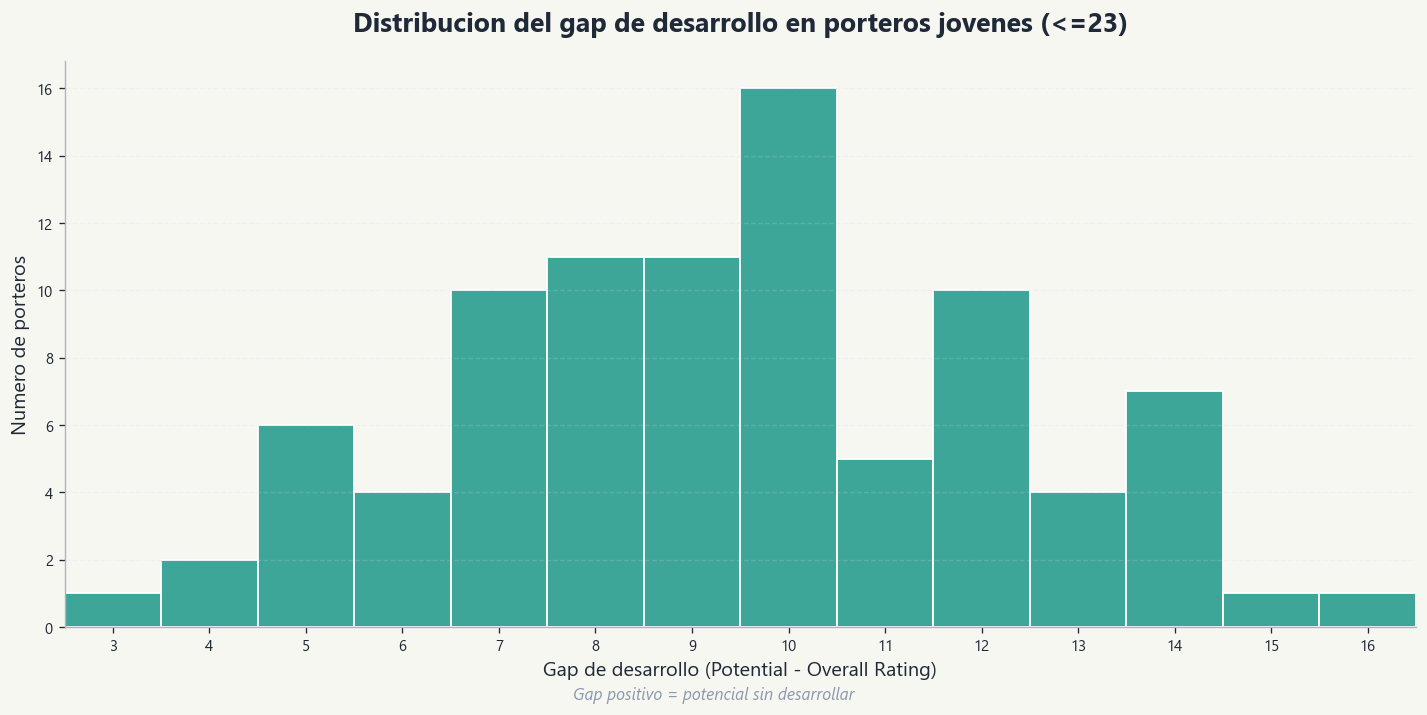

In [69]:
# Calculamos la edad de los jugadores con la misma referencia que ya venian usando
fecha_actual = pd.Timestamp("2016-01-01")
df_gap = df_player_latest_imputed.copy()
df_gap["AGE"] = (fecha_actual - df_gap["BIRTHDAY"]).dt.days / 365.25

# Filtramos solo jugadores jovenes
df_gap = df_gap[df_gap["AGE"] < 23].copy()

# Calculamos el gap entre potential y overall rating
df_gap["GAP"] = df_gap["POTENTIAL"] - df_gap["OVERALL_RATING"]

# Nos quedamos solo con porteros
df_gap_gk = df_gap[df_gap["PLAYER_TYPE"] == "GOALKEEPER"].copy()

# Como el gap es entero, usamos un bucket por valor entero
gk_min = int(df_gap_gk["GAP"].min())
gk_max = int(df_gap_gk["GAP"].max())

bins_gk = np.arange(gk_min - 0.5, gk_max + 1.5, 1)
x_ticks = np.arange(gk_min, gk_max + 1, 1)

# Estilo base del histograma
hist_style = {"alpha": 0.9, "edgecolor": "white", "linewidth": 1.2}

# Graficamos
fig, ax = plt.subplots(figsize = (12, 6))

ax.hist(df_gap_gk["GAP"].dropna(), bins = bins_gk, color = COLOR_SECUNDARIO, **hist_style)

ax.set_title("Distribucion del gap de desarrollo en porteros jovenes (<=23)", fontsize = 16, fontweight = "bold", pad = 18)
ax.set_xlabel("Gap de desarrollo (Potential - Overall Rating)", fontsize = 12)
ax.set_ylabel("Numero de porteros", fontsize = 12)
ax.grid(axis = "y", alpha = 0.2, linestyle = "--", linewidth = 0.8)

ax.set_xlim(gk_min - 0.5, gk_max + 0.5)
ax.set_xticks(x_ticks)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.5,
    0.02,
    "Gap positivo = potencial sin desarrollar",
    ha = "center",
    fontsize = 10,
    style = "italic",
    color = COLOR_NEUTRO
)

plt.tight_layout()
plt.subplots_adjust(bottom = 0.12)
plt.show()

### Análisis del gráfico

En el histograma de porteros también se observa una distribución claramente desplazada hacia valores positivos de gap. Esto sugiere que los arqueros jóvenes del dataset, al igual que los jugadores de campo, suelen conservar margen de desarrollo entre su `POTENTIAL` y su `OVERALL_RATING`.

En este caso, la distribución se concentra principalmente entre `7` y `12`, con una mediana cercana a `9`. Esto sugiere un margen de crecimiento ligeramente mayor que el observado en jugadores de campo. Sin embargo, aquí el número de observaciones es bastante menor, por lo que conviene interpretar el patrón con más cuidado y no sacar conclusiones demasiado fuertes a partir de pequeñas diferencias.

En conjunto, el gráfico indica que los porteros jóvenes también presentan espacio para mejorar, pero el análisis debe leerse con más prudencia por el tamaño de muestra. Aun así, los casos ubicados hacia la derecha de la distribución pueden verse como porteros especialmente prometedores, ya que combinan un nivel actual todavía contenido con un techo estimado más alto.

## Analisis 05: Grafico de barras de jugadores con alto potencial y overall todavia moderado

- Pregunta: Que atributos separan mejor a los jugadores jovenes con alto potencial del resto?
- Que se calcula?: La diferencia de promedios por atributo entre un grupo de jugadores jovenes de alto potencial y otro grupo de referencia de la misma edad.
- Datos a usar: df_player_latest
- Grafico: Grafico de barras horizontal.
- Insight esperado: Saber que rasgos vale mas la pena priorizar cuando se busca talento joven con margen de crecimiento.

Como el usar datos nan complicaria el analisis, usaremos el `df_player_latest_imputed`.

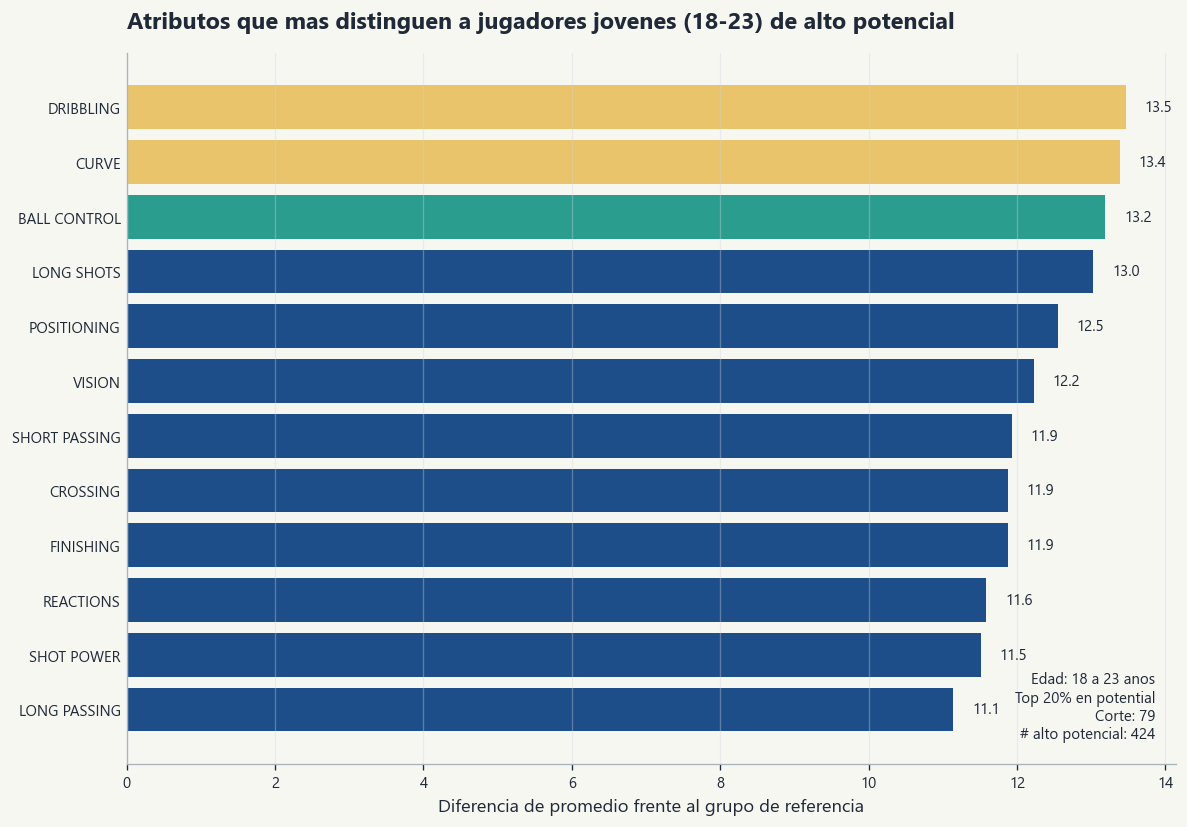

In [70]:
# Nos quedamos solo con jugadores de campo jovenes
df_young = df_player_latest_imputed.copy()
df_young = df_young[df_young["PLAYER_TYPE"] == "OUTFIELD"].copy()

# Calculamos edad aproximada al momento del snapshot
df_young["AGE"] = ((df_young["DATE"] - df_young["BIRTHDAY"]).dt.days / 365).round(1)

# Filtramos jugadores jovenes
df_young = df_young[df_young["AGE"].between(18, 23)].copy()

# Seleccionamos atributos de jugadores de campo
attr_cols = [
    "CROSSING",
    "FINISHING",
    "HEADING_ACCURACY",
    "SHORT_PASSING",
    "VOLLEYS",
    "DRIBBLING",
    "CURVE",
    "FREE_KICK_ACCURACY",
    "LONG_PASSING",
    "BALL_CONTROL",
    "ACCELERATION",
    "SPRINT_SPEED",
    "AGILITY",
    "REACTIONS",
    "BALANCE",
    "SHOT_POWER",
    "JUMPING",
    "STAMINA",
    "STRENGTH",
    "LONG_SHOTS",
    "AGGRESSION",
    "INTERCEPTIONS",
    "POSITIONING",
    "VISION",
    "PENALTIES",
    "MARKING",
    "STANDING_TACKLE",
    "SLIDING_TACKLE"
]

# Definimos el grupo de alto potencial como el top 20 por ciento
potential_cutoff = df_young["POTENTIAL"].quantile(0.80)

df_high_potential = df_young[df_young["POTENTIAL"] >= potential_cutoff].copy()
df_reference = df_young[df_young["POTENTIAL"] < potential_cutoff].copy()

# Calculamos diferencia de promedios por atributo
mean_diff = df_high_potential[attr_cols].mean() - df_reference[attr_cols].mean()

# Nos quedamos con los 12 atributos que mas distinguen al grupo
mean_diff = mean_diff.sort_values(ascending=False).head(12).sort_values()

# Preparamos labels y colores
labels = [col.replace("_", " ") for col in mean_diff.index]

bar_colors = [COLOR_PRINCIPAL] * len(mean_diff)
if len(bar_colors) >= 3:
    bar_colors[-1] = COLOR_RESALTE
    bar_colors[-2] = COLOR_RESALTE
    bar_colors[-3] = COLOR_SECUNDARIO

# Graficamos
fig, ax = plt.subplots(figsize = (10, 7))
bars = ax.barh(labels, mean_diff.values, color = bar_colors)

# Agregamos el valor al final de cada barra
for bar, value in zip(bars, mean_diff.values):
    ax.text(value + 0.25, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va = "center", fontsize = 9)

ax.axvline(0, color = COLOR_NEUTRO, linewidth = 1.2)

ax.set_title("Atributos que mas distinguen a jugadores jovenes (18-23) de alto potencial", loc = "left", pad = 15)
ax.set_xlabel("Diferencia de promedio frente al grupo de referencia")
ax.set_ylabel("")
ax.grid(axis = "x")
ax.tick_params(axis = "y", length = 0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(0.98, 0.03, f"Edad: 18 a 23 anos\nTop 20% en potential\nCorte: {potential_cutoff:.0f}\n# alto potencial: {len(df_high_potential)}", transform = ax.transAxes, ha = "right", va = "bottom", fontsize = 9)

fig.tight_layout()
plt.show()

### Análisis del gráfico

En este gráfico se observa que los jugadores jóvenes de alto potencial no se diferencian tanto por atributos defensivos o físicos puros, sino sobre todo por rasgos técnicos y ofensivos. Los atributos que más sobresalen son `DRIBBLING`, `CURVE`, `BALL_CONTROL`, `LONG_SHOTS`, `POSITIONING` y `VISION`, lo que sugiere que el techo de desarrollo suele estar más asociado con calidad técnica y capacidad ofensiva que con fuerza o juego defensivo.

También destaca que `SHORT_PASSING`, `CROSSING`, `SHOT_POWER` y `REACTIONS` aparecen entre las diferencias más altas. Esto sugiere que los jugadores más prometedores no solo tienen habilidad individual, sino también mejores recursos para participar en la circulación del balón y resolver jugadas con más calidad.

En conjunto, el gráfico sugiere que, al buscar talento joven con margen de crecimiento, conviene priorizar perfiles con buena técnica ofensiva, control de balón y lectura de juego. De todos modos, este resultado debe interpretarse como una asociación y no como causalidad, ya que tener estos atributos no garantiza por sí solo que un jugador alcance su potencial.

## Analisis 06: Grafico de anillo del margen de victoria en los partidos

Pregunta: La mayoria de los partidos se decide por margenes pequenos?
Que se calcula?: La distribucion de la diferencia absoluta de goles, agrupada en categorias como 0, 1, 2 y 3+.
Datos a usar: Match, o idealmente df_match_base con goal_diff_abs ya calculado.
Grafico: Gráfico de anillo (donut chart) con porcentajes y etiqueta explicativa de diferencia absoluta de goles.
Insight esperado: Mostrar si los partidos suelen ser cerrados y si pequenos cambios pueden tener mucho impacto en el resultado.

Falta ajustar detalles

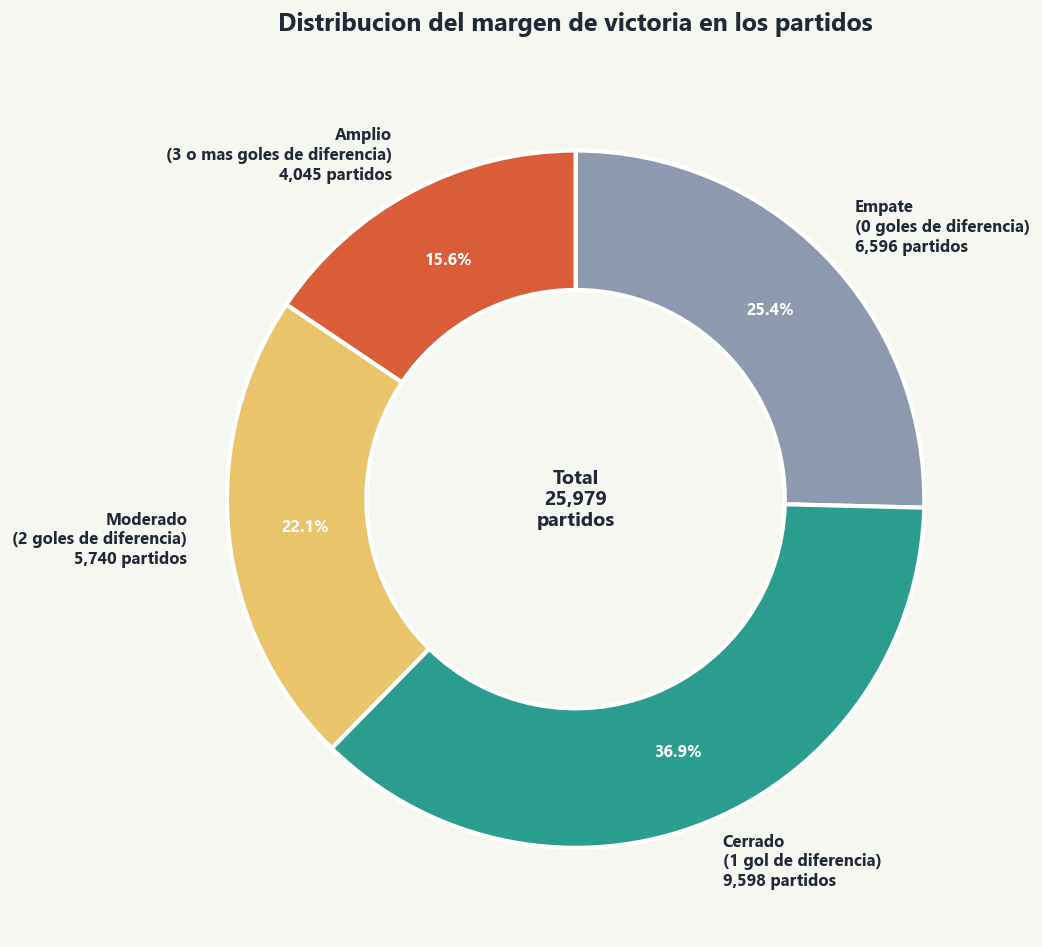

In [71]:
# Nos quedamos con un solo registro por partido
df_matches = df_team_match[df_team_match["IS_HOME"] == 1].copy()

# Se define categorias segun el margen absoluto de goles
def categorizar_margen(abs_diff):
    if abs_diff == 0:
        return "0 (Empate)"
    elif abs_diff == 1:
        return "1 (Cerrado)"
    elif abs_diff == 2:
        return "2 (Moderado)"
    else:
        return "3+ (Amplio)"

df_matches["MARGEN_CATEGORIA"] = df_matches["ABS_GOAL_DIFF"].apply(categorizar_margen)

# Se cuentan frecuencias y calculamos porcentajes
margin_order = ["0 (Empate)", "1 (Cerrado)", "2 (Moderado)", "3+ (Amplio)"]

margin_counts = (df_matches["MARGEN_CATEGORIA"].value_counts().reindex(margin_order, fill_value = 0))

margin_pct = margin_counts / margin_counts.sum() * 100

# Preparamos etiquetas con cantidad de partidos
label_map = {
    "0 (Empate)": "Empate\n(0 goles de diferencia)",
    "1 (Cerrado)": "Cerrado\n(1 gol de diferencia)",
    "2 (Moderado)": "Moderado\n(2 goles de diferencia)",
    "3+ (Amplio)": "Amplio\n(3 o mas goles de diferencia)"
}

labels = [f"{label_map[categoria]}\n{margin_counts.loc[categoria]:,} partidos" for categoria in margin_order]

# Se fijan colores para que el grafico sea consistente con la paleta de colores seleccionada
donut_colors = [COLOR_NEUTRO, COLOR_SECUNDARIO, COLOR_RESALTE, COLOR_ALERTA]

# Graficamos el anillo
fig, ax = plt.subplots(figsize = (11, 8))

wedges, texts, autotexts = ax.pie(
    margin_pct.values,
    labels = labels,
    autopct = "%1.1f%%",
    startangle = 90,
    counterclock = False,
    colors = donut_colors,
    wedgeprops = dict(width = 0.40, edgecolor = "white", linewidth = 2.5),
    pctdistance = 0.78,
    labeldistance = 1.12,
    textprops = dict(fontsize = 10, fontweight = "bold", color = COLOR_TEXTO)
)

# Ajustamos el estilo de los porcentajes dentro del anillo
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(10)
    autotext.set_fontweight("bold")

# Texto central
ax.text(0, 0, f"Total\n{int(margin_counts.sum()):,}\npartidos", ha = "center", va = "center", fontsize = 12, fontweight = "bold", color = COLOR_TEXTO)

# Titulo
ax.set_title("Distribucion del margen de victoria en los partidos", fontsize = 15, fontweight = "bold", pad = 20)

plt.tight_layout()
plt.show()

### Análisis del gráfico

En el gráfico de anillo se observa que la categoría más frecuente es la de partidos `Cerrados`, es decir, aquellos definidos por `1 gol de diferencia`, con `9,598` partidos, equivalentes a aproximadamente `37.0%` del total. Además, si se suman los `Empates` y los partidos `Cerrados`, se obtiene alrededor de `62.3%` de todos los encuentros. Esto indica que la mayor parte de los partidos del dataset se mueve en márgenes pequeños y competitivos.

Por otro lado, los partidos `Moderados`, definidos por `2 goles de diferencia`, representan cerca de `22.1%`, mientras que los partidos `Amplios`, con `3 o más goles de diferencia`, son los menos frecuentes con aproximadamente `15.6%`. Esto sugiere que los resultados abultados existen, pero son claramente menos comunes que los partidos ajustados.

En conjunto, el gráfico respalda la idea de que la mayoría de los partidos suelen ser cerrados. Desde una perspectiva de análisis deportivo, esto sugiere que pequeñas diferencias de rendimiento, decisiones tácticas o momentos puntuales del juego pueden tener un impacto grande en el resultado final, porque los márgenes amplios no son la norma sino la excepción.

## Analisis 07 - Boxplot de distribucion de atributos altas promesas vs promedio jovenes


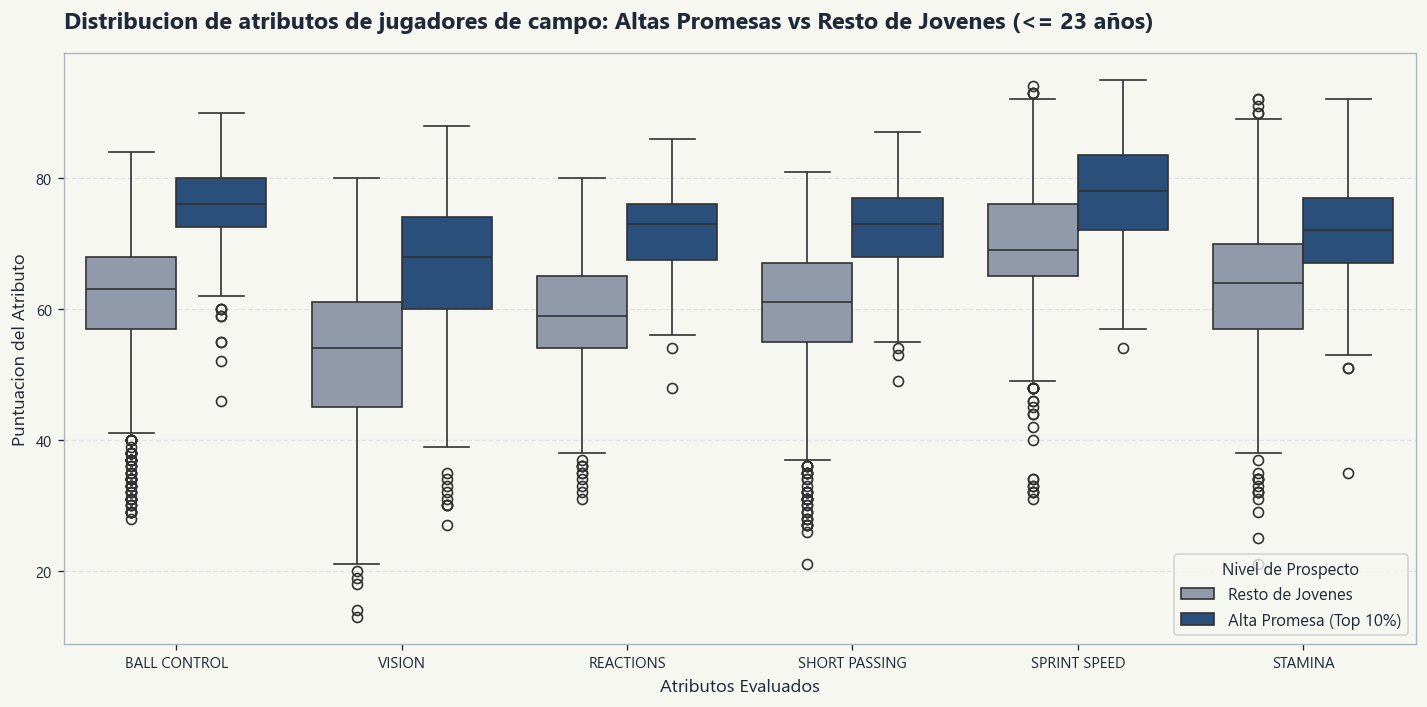

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# Definimos los colores (rosa para las promesas, gris para el resto)
paleta_boxplot = {"Alta Promesa (Top 10%)": COLOR_PRINCIPAL, "Resto de Jovenes": COLOR_NEUTRO}

# Nos quedamos solo con jugadores de campo jovenes
df_young = df_player_latest_imputed.copy()
df_young = df_young[df_young["PLAYER_TYPE"] == "OUTFIELD"].copy()

# Calculamos edad aproximada al momento del snapshot
df_young["AGE"] = ((df_young["DATE"] - df_young["BIRTHDAY"]).dt.days / 365).round(1)

# Filtramos para comparar solo jugadores jovenes (<= 23 años)
df_young = df_young[df_young["AGE"] <= 23].copy()
 
# Definimos el umbral del Top 10% de potencial
umbral_top = df_young["POTENTIAL"].quantile(0.90)
 
# Creamos una nueva columna para clasificar a los jugadores
df_young["PROSPECT_LEVEL"] = np.where(df_young["POTENTIAL"] >= umbral_top, "Alta Promesa (Top 10%)", "Resto de Jovenes")
 
# Seleccionamos 6 atributos clave para que el Boxplot sea legible
atributos = ['BALL_CONTROL', 'VISION', 'REACTIONS', 'SHORT_PASSING', 'SPRINT_SPEED', 'STAMINA']
 
# Transformamos los datos a formato largo (melt) para que Seaborn pueda agruparlos
df_melted = df_young.melt(id_vars=["PROSPECT_LEVEL"], value_vars=atributos, var_name="ATRIBUTO", value_name="PUNTUACION")
 
# Limpiamos los nombres de los atributos quitando el guion bajo
df_melted["ATRIBUTO"] = df_melted["ATRIBUTO"].str.replace("_", " ")
 
# Construimos y mostramos la grafica
fig, ax = plt.subplots(figsize=(12, 6))
 
sns.boxplot(data=df_melted, x="ATRIBUTO", y="PUNTUACION", hue="PROSPECT_LEVEL", palette=paleta_boxplot, ax=ax)
 
# Titulos y etiquetas
ax.set_title("Distribucion de atributos de jugadores de campo: Altas Promesas vs Resto de Jovenes (<= 23 años)", loc="left", pad=15)
ax.set_xlabel("Atributos Evaluados")
ax.set_ylabel("Puntuacion del Atributo")
 
# Movemos la leyenda para que no tape los datos
sns.move_legend(ax, "lower right", title="Nivel de Prospecto")
ax.grid(axis='y', linestyle='--', alpha=0.6)
 
fig.tight_layout()
plt.show() 

### Análisis del gráfico

El boxplot muestra que el grupo de `Alta Promesa (Top 10%)` presenta distribuciones más altas que el grupo de `Resto de Jóvenes` en los seis atributos evaluados. Esto se nota porque, en todos los casos, la mediana de las altas promesas queda por encima de la mediana del resto, lo que indica una ventaja consistente y no aislada en un solo atributo.

Las diferencias más marcadas aparecen en atributos como `Visión`, `Control de Balón`, `Reacciones` y `Pase Corto`. Esto sugiere que los jugadores jóvenes con mayor potencial no solo destacan por condiciones físicas, sino también por atributos técnicos y de lectura del juego. En `Velocidad Sprint` y `Resistencia` también se observa una ventaja para las altas promesas, aunque la separación entre grupos parece algo menor.

En conjunto, la gráfica sugiere que el potencial alto en jugadores jóvenes está asociado a un perfil más completo y balanceado. Es decir, las altas promesas no sobresalen solo en un atributo puntual, sino que tienden a mantener niveles superiores en varias dimensiones importantes del rendimiento.

## Analisis 08 - Grafico de lineas de nivel promedio de jugador por edad

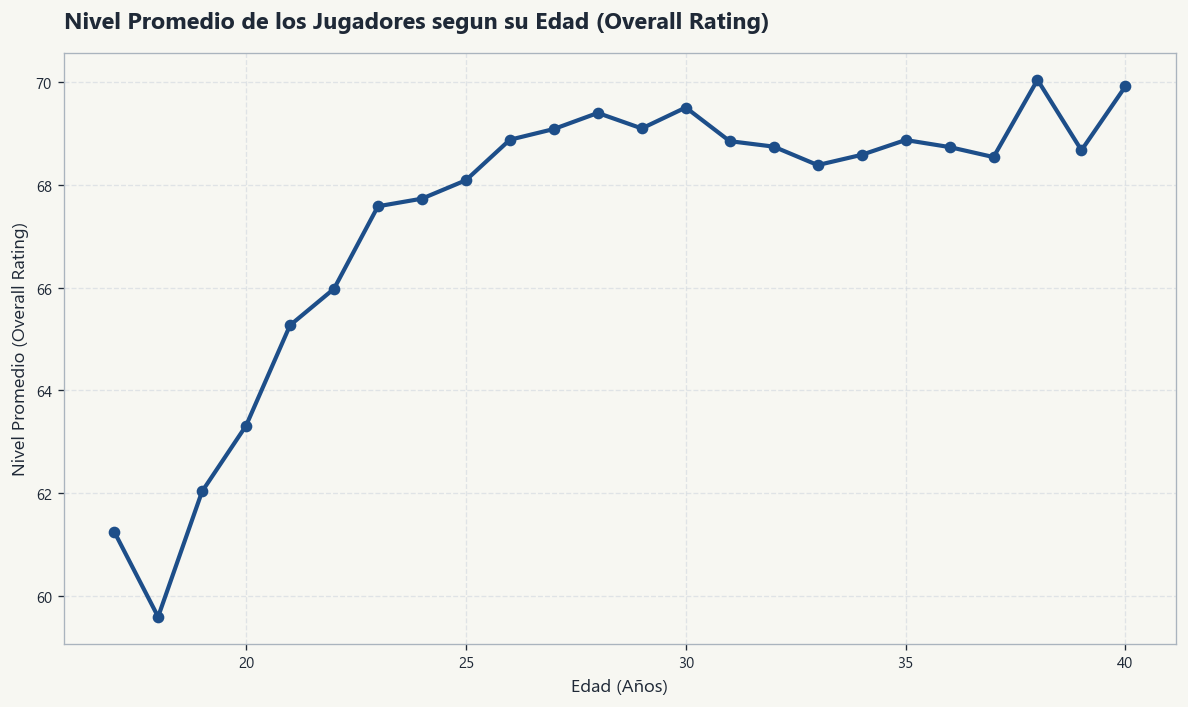

In [75]:

df_player = df_player_latest.copy()
df_player["AGE"] = (df_player["DATE"] - df_player["BIRTHDAY"]).dt.days // 365

# 4. Limpieza de ruido: Contamos cuántos jugadores hay por cada edad
conteo_edades = df_player.groupby("AGE").size()

# Nos quedamos solo con edades que tengan al menos 10 jugadores registrados
# para evitar que un solo jugador muy viejo o muy joven altere el promedio
edades_validas = conteo_edades[conteo_edades >= 10].index
df_linea = df_player[df_player["AGE"].isin(edades_validas)]

# 5. Calculamos el promedio del nivel (OVERALL_RATING) por cada edad
promedio_por_edad = df_linea.groupby("AGE")["OVERALL_RATING"].mean()

# 6. Construimos y mostramos la grafica
fig, ax = plt.subplots(figsize=(10, 6))

# Grafico de lineas con marcadores ('o') en cada punto para que se vea claro
ax.plot(promedio_por_edad.index, promedio_por_edad.values, marker='o', 
        color=COLOR_PRINCIPAL, linewidth=2.5, markersize=6)

# Titulos y etiquetas
ax.set_title("Nivel Promedio de los Jugadores segun su Edad (Overall Rating)", loc="left", pad=15)
ax.set_xlabel("Edad (Años)")
ax.set_ylabel("Nivel Promedio (Overall Rating)")

# Agregamos una cuadricula sutil para facilitar la lectura de los puntos
ax.grid(linestyle='--', alpha=0.6)

fig.tight_layout()
plt.show()

### Análisis del gráfico

Al observar la curva de tendencia en este gráfico de líneas, podemos identificar con claridad las tres etapas biológicas y deportivas que definen la carrera de un futbolista profesional:

- Fase de crecimiento: desde las edades más tempranas (`16-18` años), la línea muestra una pendiente ascendente constante y pronunciada. Es en esta etapa donde los jugadores adquieren madurez táctica, experiencia y desarrollo físico.
- El "prime" o pico de rendimiento: la curva alcanza su punto más alto y forma una "meseta" típica entre los `27` y los `31` años. Es en esta franja donde el jugador encuentra el balance perfecto: combina su máxima experiencia futbolística con un físico aún en óptimas condiciones.
- Fase de declive: a partir de los `32` años, la línea comienza un descenso evidente, reflejando la pérdida natural de capacidades físicas, como velocidad, explosividad o resistencia, que termina por afectar la valoración general.

Este gráfico dicta la lógica financiera y deportiva para armar una plantilla equilibrada. Si el equipo busca éxito inmediato para competir por un campeonato, debe apostar por jugadores en su "prime" (`27-30` años), sabiendo que su costo será el más elevado. En cambio, si la directiva busca construir un proyecto a mediano plazo y generar plusvalía, la inversión debe ir hacia la fase de crecimiento (`20-23` años), adquiriendo talento cuyo rendimiento y valor de mercado estadísticamente irán al alza.

## Analisis 09 - Bubbleplot de formaciones: rendimiento vs frecuencia de uso

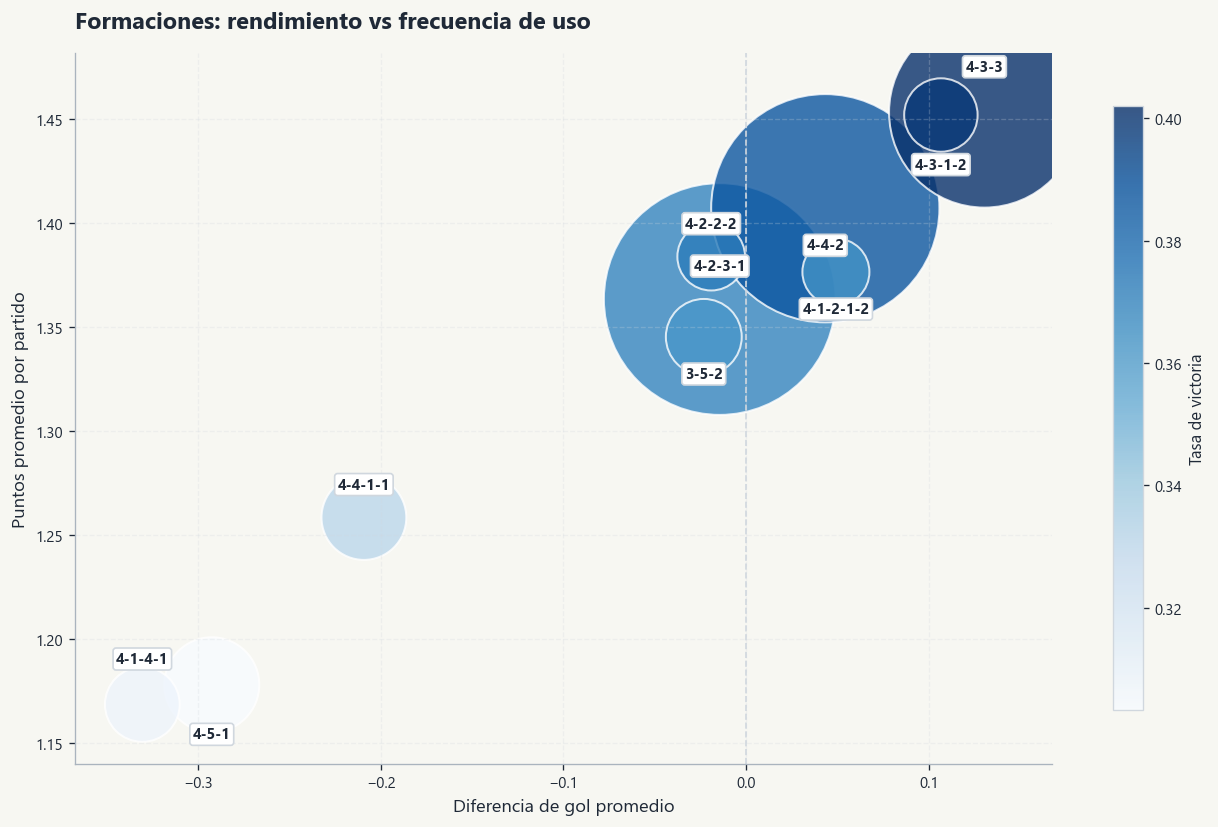

In [80]:
df_form = (
    df_team_match
    .dropna(subset=["FORMATION"])
    .groupby("FORMATION")
    .agg(
        count=("MATCH_ID", "count"),
        avg_points=("POINTS", "mean"),
        avg_goal_diff=("GOAL_DIFF", "mean"),
        win_rate=("RESULT", lambda x: (x == "W").mean())
    )
    .reset_index()
)

df_form = (df_form[df_form["count"] >= 50].sort_values("count", ascending=False).head(10))

fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    df_form["avg_goal_diff"],
    df_form["avg_points"],
    s=df_form["count"] * 1.5,
    c=df_form["win_rate"],
    cmap="Blues",
    alpha=0.8,
    edgecolors="white",
    linewidth=1.2
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label("Tasa de victoria", fontsize=10, color=COLOR_TEXTO)
cbar.outline.set_edgecolor(COLOR_GRID)

offsets = [0.012, -0.014, 0.018, -0.020]

for i, row in enumerate(df_form.itertuples()):
    dy = offsets[i % len(offsets)]

    ax.text(
        row.avg_goal_diff,
        row.avg_points + dy,
        row.FORMATION,
        ha="center",
        va="bottom" if dy > 0 else "top",
        fontsize=9,
        fontweight="bold",
        color=COLOR_TEXTO,
        bbox=dict(
            facecolor="white",
            edgecolor=COLOR_GRID,
            boxstyle="round,pad=0.2"
        )
    )

ax.axvline(0, color=COLOR_GRID, linestyle="--", linewidth=1)
ax.set_title("Formaciones: rendimiento vs frecuencia de uso", loc="left", pad=15)
ax.set_xlabel("Diferencia de gol promedio")
ax.set_ylabel("Puntos promedio por partido")
ax.grid(alpha=0.25, linestyle="--")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.margins(x=0.08, y=0.10)

plt.tight_layout()
plt.show()

### Análisis del gráfico

El bubble plot sugiere que no todas las formaciones combinan del mismo modo frecuencia de uso y rendimiento. En la zona superior derecha, donde coinciden más puntos por partido y una diferencia de gol promedio menos negativa o incluso positiva, aparecen esquemas como `4-3-3`, `4-4-2` y `4-2-3-1`. Entre ellas, `4-2-3-1` destaca especialmente porque combina un rendimiento competitivo con una burbuja grande, es decir, con una muestra amplia de partidos, lo que hace más confiable la señal.

También aparecen algunas formaciones con buen desempeño, pero con menor respaldo de muestra, como `3-5-2` y otras variantes cercanas al bloque superior. Esto sugiere que pueden ser opciones interesantes, pero conviene ser más prudente al interpretarlas, ya que una menor frecuencia de uso hace más difícil separar un patrón estable de un resultado puntual.

En el extremo opuesto, `5-3-2`, `4-5-1` y `4-1-4-1` se ubican en la zona de peor balance, con menos puntos por partido y una diferencia de gol promedio más negativa. En conjunto, la gráfica sugiere que no basta con mirar qué formación se usa más: conviene priorizar esquemas que mantengan un equilibrio entre frecuencia y resultados, y en ese sentido `4-2-3-1` y `4-4-2` parecen alternativas más sólidas que otras formaciones menos consistentes.

## Analisis 10

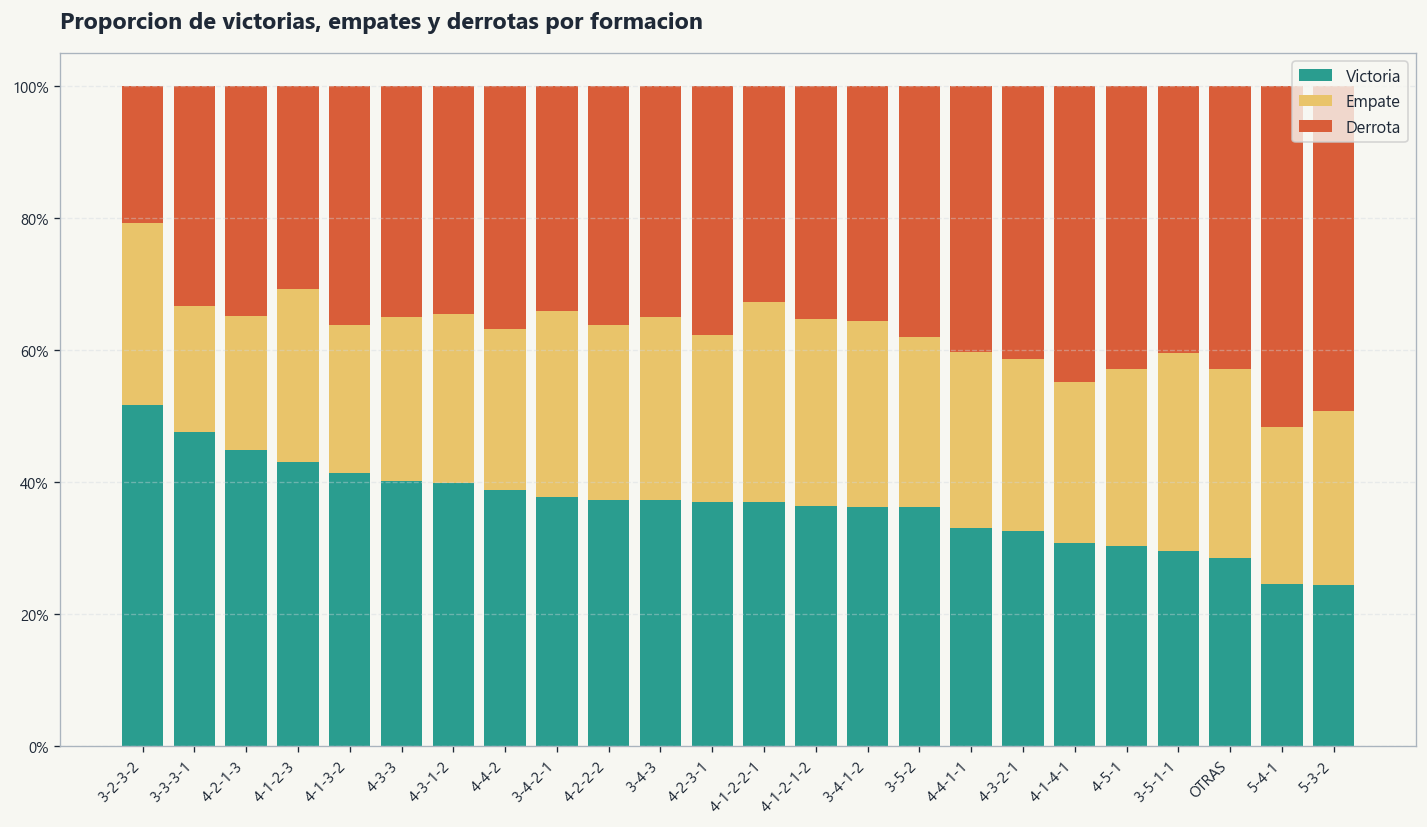

In [83]:
df_form = df_team_match.copy()
 
# Eliminamos nulos
df_form = df_form.dropna(subset=["FORMATION", "RESULT"])
 
# Convertimos a mayusculas por seguridad
df_form["RESULT"] = df_form["RESULT"].astype(str).str.upper()
 
# Mapeo flexible
map_result = {
    "W": "WIN", "WIN": "WIN", "VICTORY": "WIN", "VICTORIA": "WIN",
    "D": "DRAW", "DRAW": "DRAW", "EMPATE": "DRAW",
    "L": "LOSS", "LOSS": "LOSS", "DEFEAT": "LOSS", "DERROTA": "LOSS"
}
 
df_form["RESULT_CLEAN"] = df_form["RESULT"].map(map_result)
 
# Eliminamos valores que no se pudieron mapear
df_form = df_form.dropna(subset=["RESULT_CLEAN"])
 
 
conteo_formaciones = df_form["FORMATION"].value_counts()
 
# Umbral mas flexible
MIN_PARTIDOS = 20
 
formaciones_validas = conteo_formaciones[conteo_formaciones >= MIN_PARTIDOS].index
 
df_form["FORMATION_CLEAN"] = df_form["FORMATION"].apply(
    lambda x: x if x in formaciones_validas else "OTRAS"
)
 
 
tabla = pd.crosstab(
    df_form["FORMATION_CLEAN"],
    df_form["RESULT_CLEAN"],
    normalize="index"
)
 
# Asegurar columnas
for col in ["WIN", "DRAW", "LOSS"]:
    if col not in tabla.columns:
        tabla[col] = 0
 
tabla = tabla[["WIN", "DRAW", "LOSS"]]
 
# Ordenar por victorias
tabla = tabla.sort_values(by="WIN", ascending=False)
 
# grafico
 
fig, ax = plt.subplots(figsize=(12, 7))
 
x = np.arange(len(tabla.index))
 
ax.bar(x, tabla["WIN"], label="Victoria", color=COLOR_SECUNDARIO)
ax.bar(x, tabla["DRAW"], bottom=tabla["WIN"], label="Empate", color=COLOR_RESALTE)
ax.bar(
    x,
    tabla["LOSS"],
    bottom=tabla["WIN"] + tabla["DRAW"],
    label="Derrota",
    color=COLOR_ALERTA
)
 
ax.set_xticks(x)
ax.set_xticklabels(tabla.index, rotation=45, ha="right")
 
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
 
ax.set_title("Proporcion de victorias, empates y derrotas por formacion", loc="left", pad=15)
 
ax.grid(axis="y", linestyle="--", alpha=0.4)
 
ax.legend()
 
plt.tight_layout()
plt.show()

### Análisis del gráfico

Al ver los resultados, se nota que no todas las formaciones se comportan igual en la cancha. Hay algunas que son más confiables: no siempre ganan, pero pierden poco y te mantienen compitiendo partido a partido, lo cual es clave en torneos largos. Otras son más arriesgadas: te pueden dar muchas victorias, pero también más derrotas, como si el equipo jugara al límite; estas pueden ser útiles cuando necesitas ir por todo, por ejemplo en partidos decisivos.

También están las formaciones más conservadoras, que tienden a empatar mucho: no arriesgan demasiado, pero tampoco marcan tanta diferencia. Para un entrenador, esto se traduce en elegir la formación no solo por estilo, sino por el momento: usar esquemas más sólidos cuando buscas regularidad y control, y formaciones más agresivas cuando necesitas ganar sí o sí, aunque implique asumir más riesgo.